<a href="https://colab.research.google.com/github/Ram6023/ML-Practice/blob/main/ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('HR-Employee-Attrition.csv')
display(df.head())

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


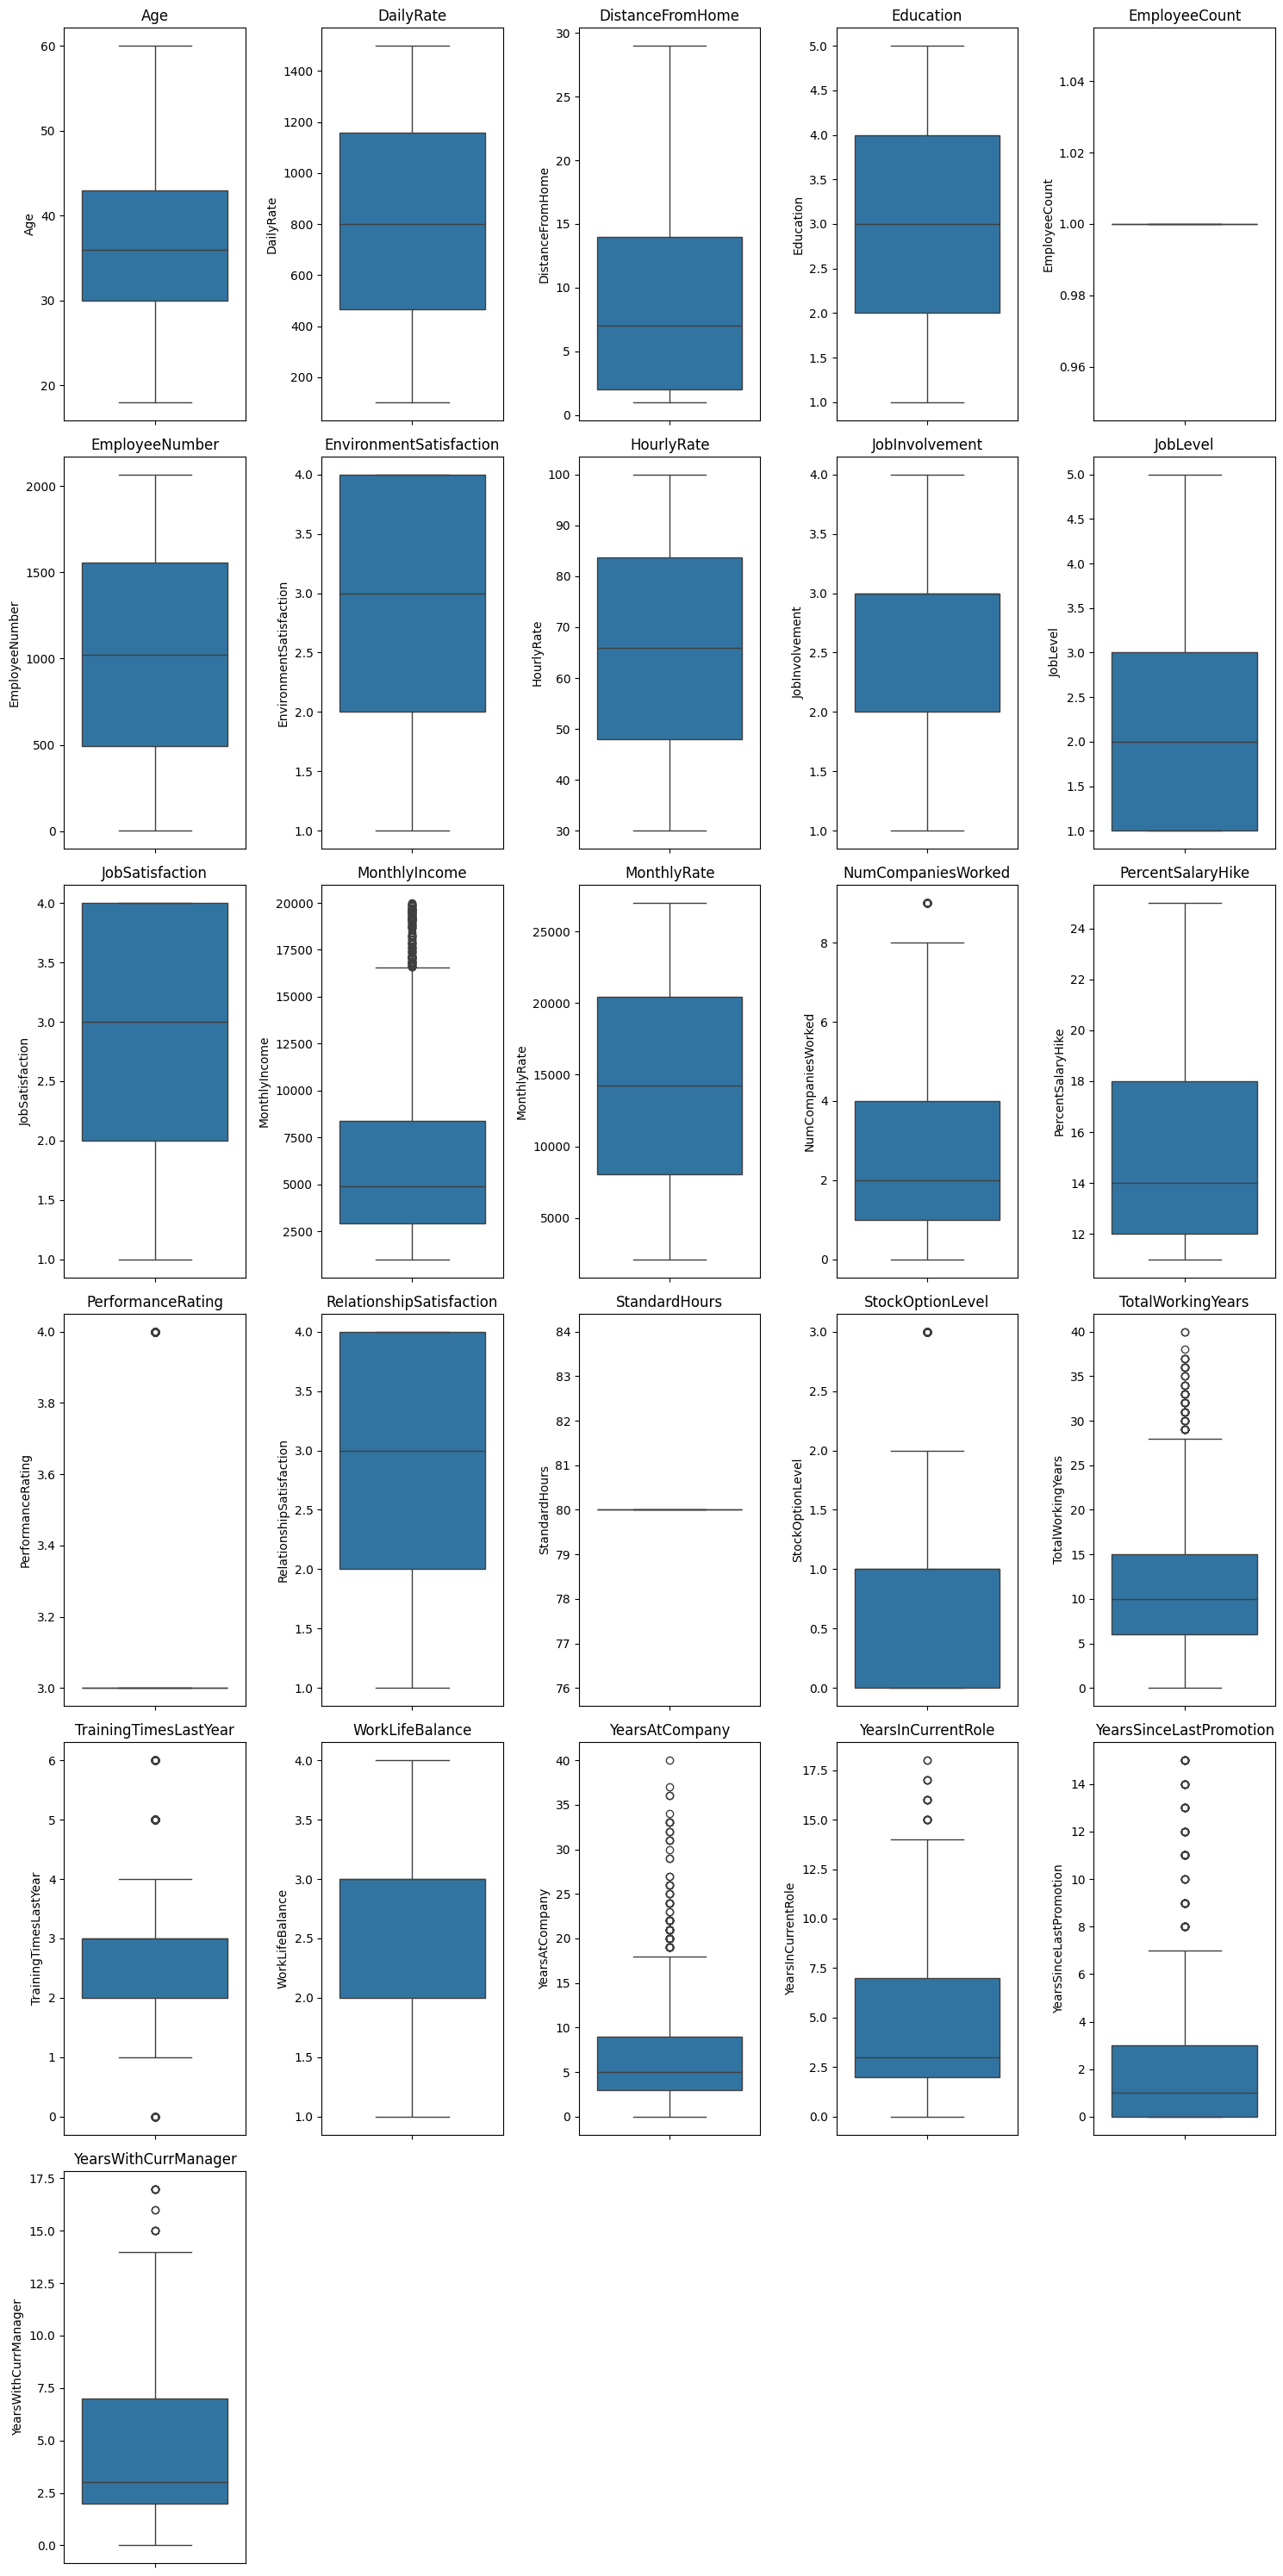

In [8]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

num_plots = len(numerical_cols)
num_cols = 5
num_rows = (num_plots + num_cols - 1) // num_cols

plt.figure(figsize=(15, 5 * num_rows))
for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [9]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
print("Attrition column converted to numerical format.")

Attrition column converted to numerical format.


In [10]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

# Exclude 'Attrition' if it accidentally got included or was not converted properly (though it should be numerical now)
if 'Attrition' in categorical_cols:
    categorical_cols = categorical_cols.drop('Attrition')

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("Categorical columns one-hot encoded.")
display(df.head())

Categorical columns one-hot encoded.


,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,1,1,2,94,3,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,1,2,3,61,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,1,4,4,92,2,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,1,5,4,56,3,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,7,1,40,3,...,True,False,False,False,False,False,False,True,False,False


In [11]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

print("Features (X) and target (y) have been defined.")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Features (X) and target (y) have been defined.
Shape of X: (1470, 47)
Shape of y: (1470,)


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets.")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Data split into training and testing sets.
Shape of X_train: (1176, 47)
Shape of X_test: (294, 47)
Shape of y_train: (1176,)
Shape of y_test: (294,)


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Instantiate Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)

# Instantiate Random Forest Classifier model
rf_model = RandomForestClassifier(random_state=42)

# Train Logistic Regression model
log_reg_model.fit(X_train, y_train)

# Train Random Forest Classifier model
rf_model.fit(X_train, y_train)

print("Both Logistic Regression and Random Forest models have been trained.")

Both Logistic Regression and Random Forest models have been trained.


Logistic Regression Model Evaluation:
Accuracy: 0.8980
Precision: 0.7143
Recall: 0.3846
F1-Score: 0.5000


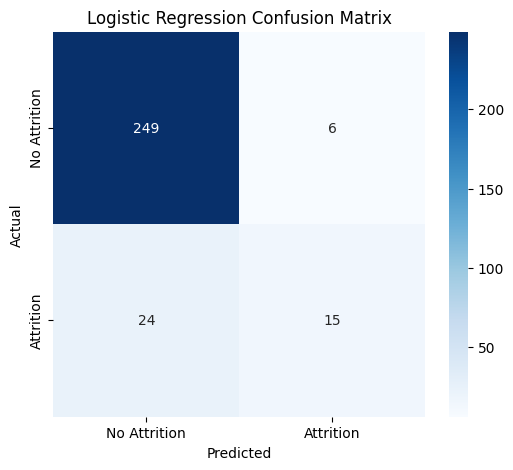


True Negatives (Correctly identified loyal employees): 249
False Positives (Incorrectly flagged loyal employees): 6
False Negatives (Missed attrition): 24
True Positives (Correctly identified attrition): 15


In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

# Evaluate Logistic Regression Model
print("Logistic Regression Model Evaluation:")
log_reg_accuracy = accuracy_score(y_test, y_pred_log_reg)
log_reg_precision = precision_score(y_test, y_pred_log_reg)
log_reg_recall = recall_score(y_test, y_pred_log_reg)
log_reg_f1 = f1_score(y_test, y_pred_log_reg)

print(f"Accuracy: {log_reg_accuracy:.4f}")
print(f"Precision: {log_reg_precision:.4f}")
print(f"Recall: {log_reg_recall:.4f}")
print(f"F1-Score: {log_reg_f1:.4f}")

# Confusion Matrix for Logistic Regression
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues', xticklabels=['No Attrition', 'Attrition'], yticklabels=['No Attrition', 'Attrition'])
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nTrue Negatives (Correctly identified loyal employees):", cm_log_reg[0,0])
print("False Positives (Incorrectly flagged loyal employees):", cm_log_reg[0,1])
print("False Negatives (Missed attrition):", cm_log_reg[1,0])
print("True Positives (Correctly identified attrition):", cm_log_reg[1,1])



Random Forest Model Evaluation:
Accuracy: 0.8776
Precision: 0.8000
Recall: 0.1026
F1-Score: 0.1818


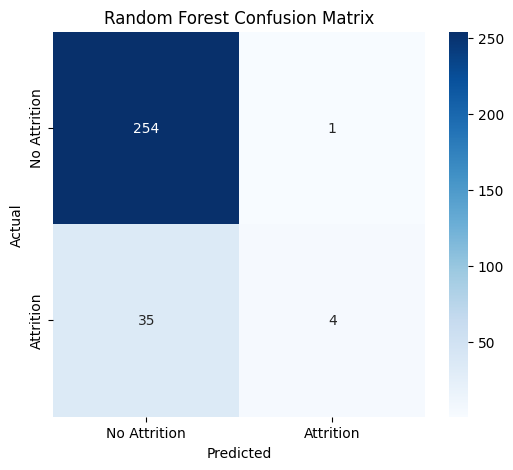


True Negatives (Correctly identified loyal employees): 254
False Positives (Incorrectly flagged loyal employees): 1
False Negatives (Missed attrition): 35
True Positives (Correctly identified attrition): 4


In [15]:
print("\nRandom Forest Model Evaluation:")
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print(f"Accuracy: {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall: {rf_recall:.4f}")
print(f"F1-Score: {rf_f1:.4f}")

# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['No Attrition', 'Attrition'], yticklabels=['No Attrition', 'Attrition'])
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nTrue Negatives (Correctly identified loyal employees):", cm_rf[0,0])
print("False Positives (Incorrectly flagged loyal employees):", cm_rf[0,1])
print("False Negatives (Missed attrition):", cm_rf[1,0])
print("True Positives (Correctly identified attrition):", cm_rf[1,1])

In [17]:
print('Logistic Regression Confusion Matrix:')
display(cm_log_reg)
print('\nRandom Forest Confusion Matrix:')
display(cm_rf)

Logistic Regression Confusion Matrix:


array([[249,   6],
       [ 24,  15]])


Random Forest Confusion Matrix:


array([[254,   1],
       [ 35,   4]])